In [72]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
import scienceplots

plt.style.use(['science','no-latex', 'notebook'])
colors = ["#00BBF9", "#CC2836", "#F3A712","#3eb690","#A05496","#114b5f"]
markers = ['o-','s-','^-']
#mpl.rcParams.update(mpl.rcParamsDefault)

### Lorenz 96, IG vs k both with and without embeddings

In [73]:
def compute_IG(imbalances):
    return (imbalances[:,:,0] - np.min(imbalances, axis=-1)) / imbalances[:,:,0]

In [74]:
epsilons = np.linspace(0.,1.5,31)
taus = np.array([1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 70, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500])
alphas = np.linspace(0.,0.25,50)

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((len(taus),len(epsilons),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(taus),len(epsilons),len(alphas)))
for i_tau, tau in enumerate(taus):
    info_imbalances_X_to_Y[i_tau], info_imbalances_Y_to_X[i_tau] = pickle.load(open(f"./analysis/ig_allcoords/pickles/lorenz96/tau{tau}.p","rb"))
IGs_X_to_Y = compute_IG(info_imbalances_X_to_Y)
IGs_Y_to_X = compute_IG(info_imbalances_Y_to_X)

# IG, embeddings
info_imbalances_X_to_Y_emb = np.zeros((len(taus),len(epsilons),len(alphas)))
info_imbalances_Y_to_X_emb = np.zeros((len(taus),len(epsilons),len(alphas))) 
for i_tau, tau in enumerate(taus):
    info_imbalances_X_to_Y_emb[i_tau], info_imbalances_Y_to_X_emb[i_tau] = pickle.load(open(f"./analysis/ig_embeddings/pickles/lorenz96/tau{tau}.p","rb"))
IGs_X_to_Y_emb = compute_IG(info_imbalances_X_to_Y_emb)
IGs_Y_to_X_emb = compute_IG(info_imbalances_Y_to_X_emb)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


epsilon = 0.75


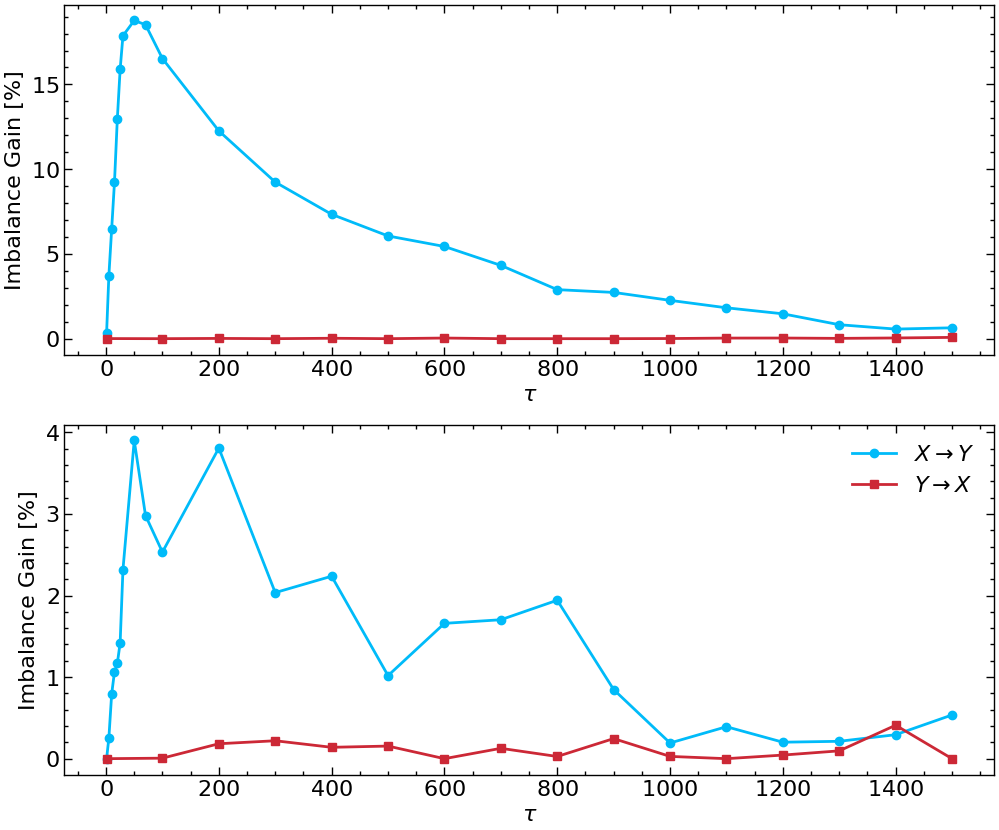

In [76]:
i_eps = 15
print(f"epsilon = {epsilons[i_eps]}")
samples_xtoy = np.append([0],np.arange(4,len(taus)))
samples_ytox = np.append([0],np.arange(12,len(taus)))

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(2,1,figsize=(12,10))

ax[0].plot(taus[samples_xtoy], 100*IGs_X_to_Y[samples_xtoy,i_eps], 'o-', color=colors[0])
ax[0].plot(taus[samples_ytox], 100*IGs_Y_to_X[samples_ytox,i_eps], 's-', color=colors[1])
ax[1].plot(taus[samples_xtoy], 100*IGs_X_to_Y_emb[samples_xtoy,i_eps], 'o-', color=colors[0], label=f"$X\\rightarrow Y$")
ax[1].plot(taus[samples_ytox], 100*IGs_Y_to_X_emb[samples_ytox,i_eps], 's-', color=colors[1], label=f"$Y\\rightarrow X$")

ax[0].set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax[1].set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax[0].legend()
ax[1].legend()

#plt.savefig("./figures/lorenz96_vs_tau_all_and_emb.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

epsilon = 1.0


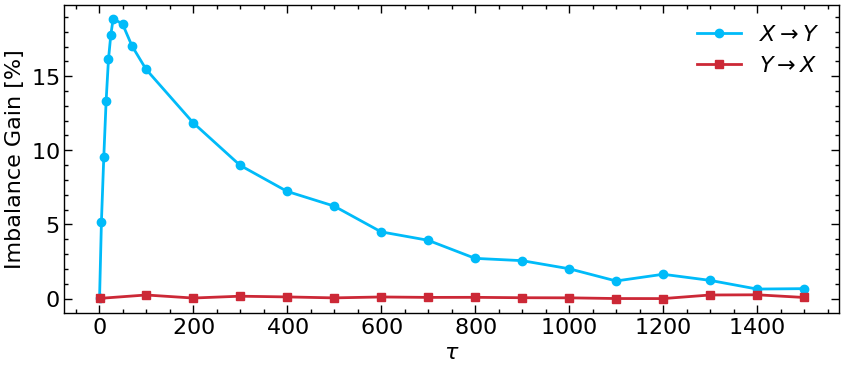

In [77]:
i_eps = 20
print(f"epsilon = {epsilons[i_eps]}")
samples_xtoy = np.append([0],np.arange(4,len(taus)))
samples_ytox = np.append([0],np.arange(12,len(taus)))

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(taus[samples_xtoy], 100*IGs_X_to_Y[samples_xtoy,i_eps], 'o-', color=colors[0], label=f"$X\\rightarrow Y$")
ax.plot(taus[samples_ytox], 100*IGs_Y_to_X[samples_ytox,i_eps], 's-', color=colors[1], label=f"$Y\\rightarrow X$")

ax.set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax.legend()

#plt.savefig("./figures/lorenz96_vs_tau.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

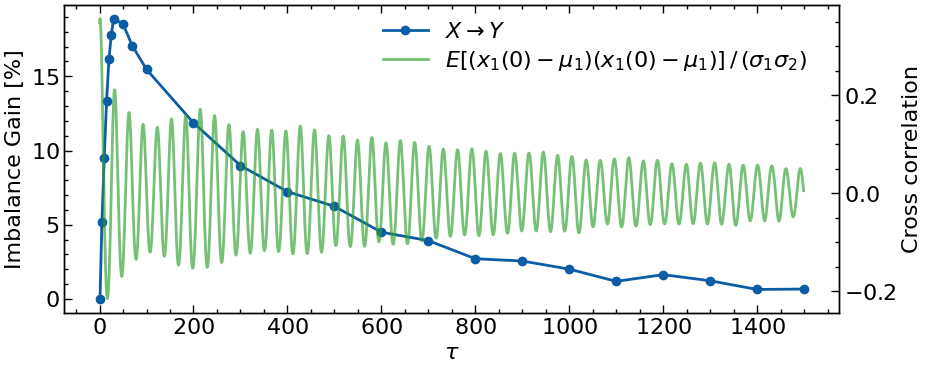

In [92]:
# compute cross correlations vs tau
i_eps = 20
import statsmodels.api as sm
trajectory = pickle.load(open(f"../fig3_errors/trajs/lorenz96/seed0_ieps{i_eps}.p","rb"))
cross_corr_x1_y1 = sm.tsa.stattools.ccf(trajectory[:,1], trajectory[:,41], adjusted=True, fft=True)

plt.rcParams['font.size'] = 18
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(taus[samples_xtoy], 100*IGs_X_to_Y[samples_xtoy,i_eps], 'o-', label=f"$X\\rightarrow Y$")

ax2 = ax.twinx()  # instantiate a second axes that shares the same x-axis
ax2.plot(cross_corr_x1_y1[:1500], '-', color="tab:green", alpha=0.65, label=f"$E[(x_1(0)-\\mu_1)(x_1(0)-\\mu_1)] \,/\, (\\sigma_1\\sigma_2)$")

ax.set(ylabel="Imbalance Gain [%]", xlabel="$\\tau$")
ax2.set(ylabel="Cross correlation")
ax.legend(loc=(0.4,0.85))
ax2.legend(loc=(0.4,0.75))

#plt.savefig("./figures/lorenz96_vs_tau.pdf", dpi=300, bbox_inches='tight', facecolor="white", transparent=False)
plt.show()

### Different Rosslers (i_eps = 14)

In [60]:
def compute_IG(imbalances):
    return (imbalances[:,0] - np.min(imbalances, axis=-1)) / imbalances[:,0]

In [61]:
ieps = 14
taus = np.array([1, 2, 3, 4, 5, 10, 15, 20, 25, 30, 50, 70, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200, 1300, 1400, 1500])
alphas = np.linspace(0.,0.5,100)

# IG, all coordinates
info_imbalances_X_to_Y = np.zeros((len(taus),len(alphas)))
info_imbalances_Y_to_X = np.zeros((len(taus),len(alphas)))
for i_tau, tau in enumerate(taus):
    info_imbalances_X_to_Y[i_tau], info_imbalances_Y_to_X[i_tau] = pickle.load(open(f"./analysis/ig_allcoords/pickles/rossler_diff/ieps{ieps}_tau{tau}.p","rb"))
IGs_X_to_Y = compute_IG(info_imbalances_X_to_Y)
IGs_Y_to_X = compute_IG(info_imbalances_Y_to_X)

In [64]:
# compute cross correlations vs tau
import statsmodels.api as sm

trajectory = pickle.load(open(f"../fig3_errors/trajs/rossler_diff/seed0_ieps{ieps}.p","rb"))

cross_corr_x1_y1 = sm.tsa.stattools.ccf(trajectory[:,1], trajectory[:,4], adjusted=True, fft=True)
cross_corr_x2_y2 = sm.tsa.stattools.ccf(trajectory[:,2], trajectory[:,5], adjusted=True, fft=True)
cross_corr_x3_y3 = sm.tsa.stattools.ccf(trajectory[:,3], trajectory[:,6], adjusted=True, fft=True)

In [66]:
cross_corr_x1_y1.shape

(205001,)

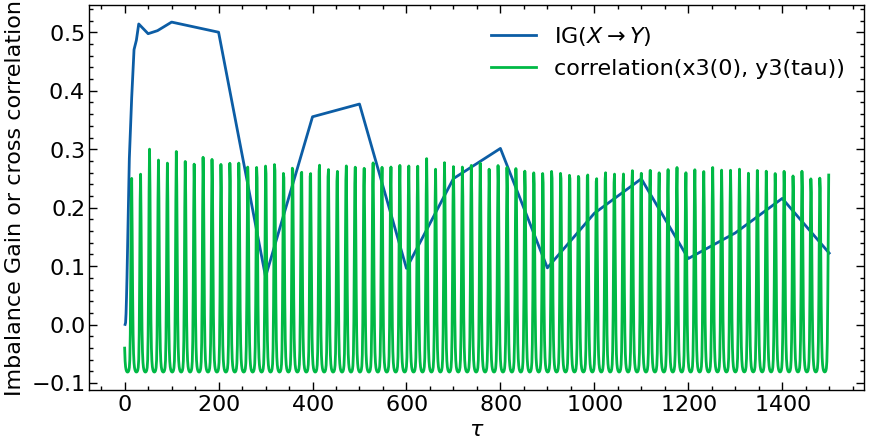

In [69]:
plt.figure(figsize=(10,5))
plt.plot(taus, IGs_X_to_Y, label="IG($X\\rightarrow Y$)")
#plt.plot(cross_corr_x1_y1[:1500], label="correlation(x1(0), y1(tau))")
#plt.plot(cross_corr_x2_y2[:1500], label="correlation(x2(0), y2(tau))")
plt.plot(cross_corr_x3_y3[:1500], label="correlation(x3(0), y3(tau))")
plt.xlabel("$\\tau$")
plt.ylabel("Imbalance Gain or cross correlation")
plt.legend()
plt.show()

In [34]:
def compute_cross_corr(x, y, last_tau=5):
    assert x.shape == y.shape, "Error: shape mismatch!"

    mean_x = x.mean()
    mean_y = y.mean()
    std_x = x.std()
    std_y = y.std()
    cross_corr = np.zeros(last_tau)
    for tau in range(1,last_tau):
        cross_corr[tau] = np.mean((x[:-tau] - mean_x) * (y[tau:] - mean_y)) / (std_x * std_y)
    return cross_corr

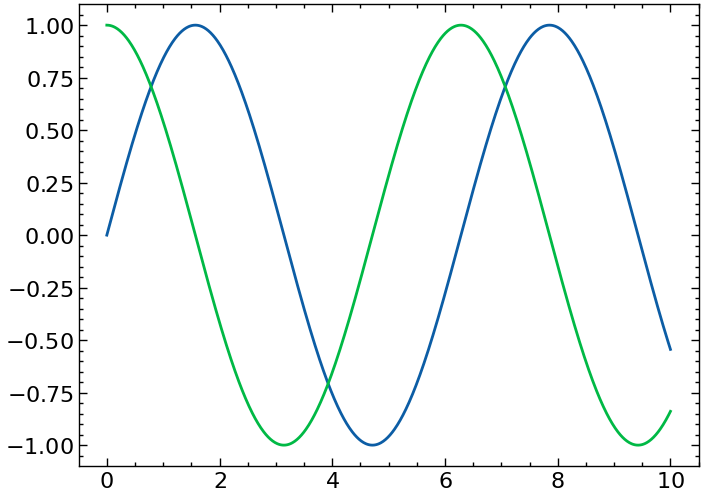

In [53]:
t = np.linspace(0,10,1000)
x = np.sin(t)
y = np.cos(t)

plt.plot(t, x)
plt.plot(t, y)

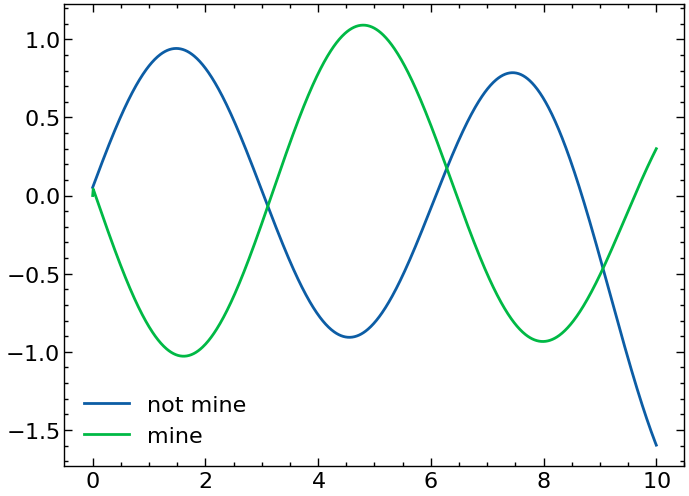

In [57]:
import statsmodels.api as sm

#calculate cross correlation
plt.plot(t, sm.tsa.stattools.ccf(x, y, adjusted=True, fft=True), label="not mine")


In [6]:
np.corrcoef(x[tau:],y[:-tau])[0,1]

1.0